# Segmentation → VNNLib property → ab-CROWN

Pipeline:

1. Load one image from a dataset (e.g. TinyImageNet).
2. Run a segmentation model (SAM2/SAM3) to get segments and bounding boxes.
3. Visualise boxes, manually pick one segment.
4. Use the bounding box to build a VNNLib property:
   - pixels *inside* the box: image ± ε
   - pixels *outside* the box: fixed to the original image value
5. (Optional) add robustness constraint for the true class.
6. Save `.vnnlib` file and run ab-CROWN.


Dataset: tinyimagenet:
1.	Tiny ImageNet is a smaller, 200-class subset of the ImageNet dataset, where each class contains 500 training images and 50 validation images.

2.	Every image is resized to 64×64 pixels, making the dataset lightweight and ideal for fast experiments, model prototyping, and academic assignments.

In [39]:
# variables:

EPSILON = 0.00039
IMG_INDEX = 7963  
VAL_IMG_DIR = DATA_ROOT / "val" / "images"

Found 10000 validation images.
Selected image: datasets/tiny-imagenet-200/val/images/val_8165.JPEG


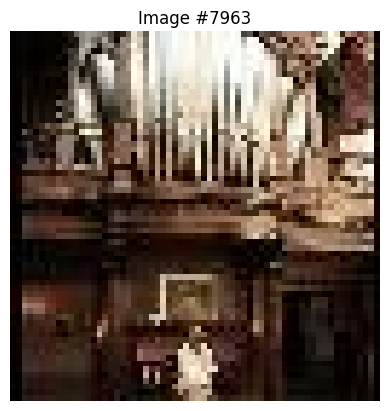

In [40]:
# show the image
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np


all_images = sorted(list(VAL_IMG_DIR.glob("*.JPEG")))
print(f"Found {len(all_images)} validation images.")

IMG_PATH = all_images[IMG_INDEX]
print("Selected image:", IMG_PATH)

# Load image
image = Image.open(IMG_PATH).convert("RGB")
image_np = np.array(image) / 255.0

plt.imshow(image_np)
plt.axis("off")
plt.title(f"Image #{IMG_INDEX}")
plt.show()

In [41]:
# loading the SAM2 as a segmentation model
from sam2.sam2_image_predictor import SAM2ImagePredictor
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

predictor = SAM2ImagePredictor.from_pretrained(
    "facebook/sam2-hiera-large",
    device=DEVICE,
)
predictor.model.eval();

In [42]:
# segmentation function:

def run_segmentation_model(
    image_np: np.ndarray,
    grid_size: int = 6,
    iou_threshold: float = 0.8,
    score_threshold: float = 0.0,
):
    """
    Use SAM2ImagePredictor to get segments from an image.

    Returns:
        segments: list of dicts like
            {
                "bbox": [x_min, y_min, x_max, y_max],
                "mask": 2D boolean array (H, W)
            }
    """
    H, W, C = image_np.shape
    assert C == 3, "Expect RGB image (H, W, 3)"

    # ---- 1. prepare image for SAM2 ----
    img_uint8 = (np.clip(image_np, 0.0, 1.0) * 255).astype(np.uint8)
    predictor.set_image(img_uint8)

    # ---- 2. build a grid of foreground points as prompts ----
    ys = np.linspace(0, H - 1, grid_size).astype(int)
    xs = np.linspace(0, W - 1, grid_size).astype(int)
    grid_y, grid_x = np.meshgrid(ys, xs, indexing="ij")
    point_coords = np.stack([grid_x.ravel(), grid_y.ravel()], axis=-1)  # (P, 2)
    point_labels = np.ones(len(point_coords), dtype=np.int64)          # all FG

    masks, scores, logits = predictor.predict(
        point_coords=point_coords[None, ...],   # (1, P, 2)
        point_labels=point_labels[None, ...],   # (1, P)
        multimask_output=True,
    )

    # ---- 3. Normalize shapes (this is where things went wrong before) ----
    masks = np.array(masks)
    scores = np.array(scores)

    # Case A: (1, P, M, H, W)
    if masks.ndim == 5:
        _, P, M, Hm, Wm = masks.shape
        masks = masks.reshape(P * M, Hm, Wm)
        scores = scores.reshape(P * M)

    # Case B: (P, M, H, W)
    elif masks.ndim == 4:
        P, M, Hm, Wm = masks.shape
        masks = masks.reshape(P * M, Hm, Wm)
        scores = scores.reshape(P * M)

    # Case C: (K, H, W)  <-- this is your current case: (3, 64, 64)
    elif masks.ndim == 3:
        K, Hm, Wm = masks.shape
        # nothing to do, already (K, H, W)

    # Case D: (H, W) single mask
    elif masks.ndim == 2:
        Hm, Wm = masks.shape
        masks = masks[None, ...]
        scores = scores.reshape(1)

    else:
        raise ValueError(f"Unexpected SAM2 mask shape: {masks.shape}")

    # Sanity check spatial dims
    if masks.shape[-2:] != (H, W):
        raise ValueError(
            f"Mask spatial size {masks.shape[-2:]} != image size {(H, W)}"
        )

    # ---- 4. turn masks into segments + deduplicate via IoU ----
    def mask_iou(a, b):
        inter = np.logical_and(a, b).sum()
        union = np.logical_or(a, b).sum()
        if union == 0:
            return 0.0
        return inter / union

    segments = []
    for mask, score in zip(masks, scores):
        if score < score_threshold:
            continue

        ys_mask, xs_mask = np.where(mask)
        if len(ys_mask) == 0:
            continue

        y_min, y_max = ys_mask.min(), ys_mask.max() + 1
        x_min, x_max = xs_mask.min(), xs_mask.max() + 1

        keep = True
        for seg in segments:
            if mask_iou(mask, seg["mask"]) > iou_threshold:
                keep = False
                break
        if not keep:
            continue

        segments.append(
            {
                "bbox": [int(x_min), int(y_min), int(x_max), int(y_max)],
                "mask": mask.astype(bool),
            }
        )

    print(f"SAM2 produced {len(segments)} unique segments.")
    return segments


# Debug SAM2 output shapes
# predictor.set_image((image_np * 255).astype(np.uint8))

# ys = np.linspace(0, image_np.shape[0] - 1, 6).astype(int)
# xs = np.linspace(0, image_np.shape[1] - 1, 6).astype(int)
# grid_y, grid_x = np.meshgrid(ys, xs, indexing="ij")
# point_coords = np.stack([grid_x.ravel(), grid_y.ravel()], axis=-1)
# point_labels = np.ones(len(point_coords), dtype=np.int64)

# masks, scores, logits = predictor.predict(
#     point_coords=point_coords[None, ...],
#     point_labels=point_labels[None, ...],
#     multimask_output=True,
# )

# print("masks.shape:", np.array(masks).shape)
# print("scores.shape:", np.array(scores).shape)
# print("logits.shape:", np.array(logits).shape)

In [43]:
# show the segments with bbox
def show_segment_with_bbox(image_np, segment, title=""):
    H, W, _ = image_np.shape
    bbox = segment["bbox"]
    mask = segment["mask"]

    fig, ax = plt.subplots(1, 2, figsize=(8, 4))

    # original with bbox
    ax[0].imshow(image_np)
    x_min, y_min, x_max, y_max = bbox
    # draw rectangle
    ax[0].add_patch(
        plt.Rectangle(
            (x_min, y_min),
            x_max - x_min,
            y_max - y_min,
            fill=False,
            linewidth=2,
        )
    )
    ax[0].set_title("Bounding box")
    ax[0].axis("off")

    # masked segment
    seg_img = image_np.copy()
    # grey out everything outside the mask
    seg_img[~mask] = 0.5
    ax[1].imshow(seg_img)
    ax[1].set_title("Segment mask")
    ax[1].axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


SAM2 produced 3 unique segments.
Found 3 segments
Segment 0: bbox=[5, 0, 63, 64]


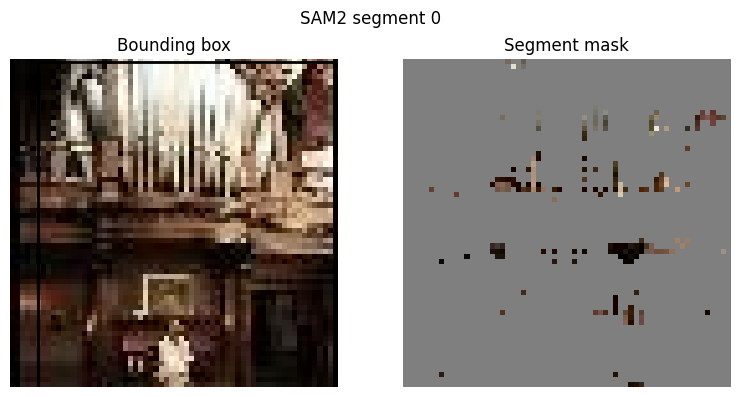

Segment 1: bbox=[0, 0, 64, 64]


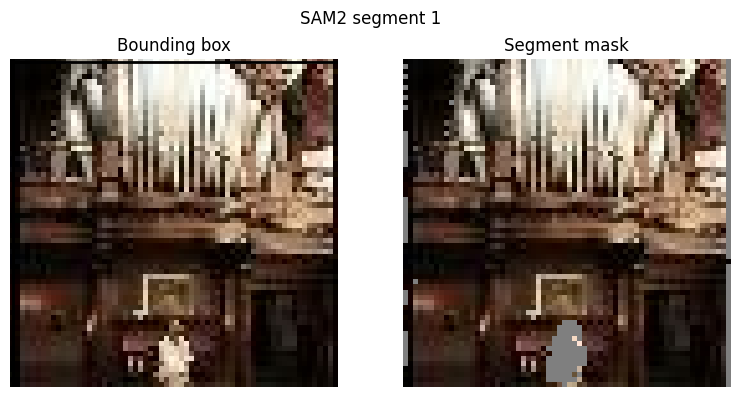

Segment 2: bbox=[0, 0, 63, 64]


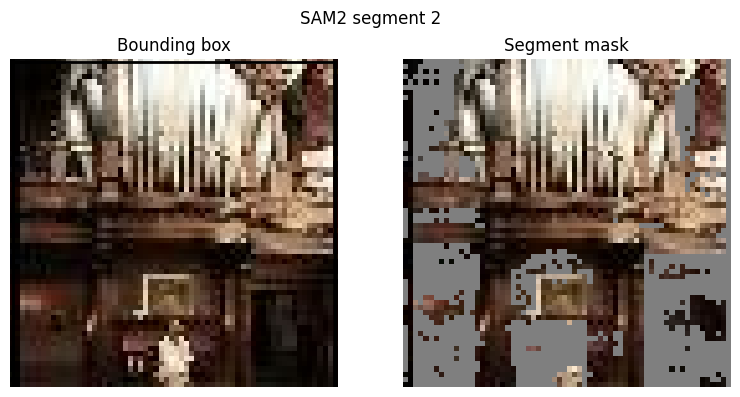

In [44]:
segments = run_segmentation_model(image_np, grid_size=6, score_threshold=0.0)
print(f"Found {len(segments)} segments")
for i, seg in enumerate(segments):
    print(f"Segment {i}: bbox={seg['bbox']}")
    show_segment_with_bbox(image_np, seg, title=f"SAM2 segment {i}")

Chosen segment: 1
Dilated bbox: [0, 0, 64, 64]


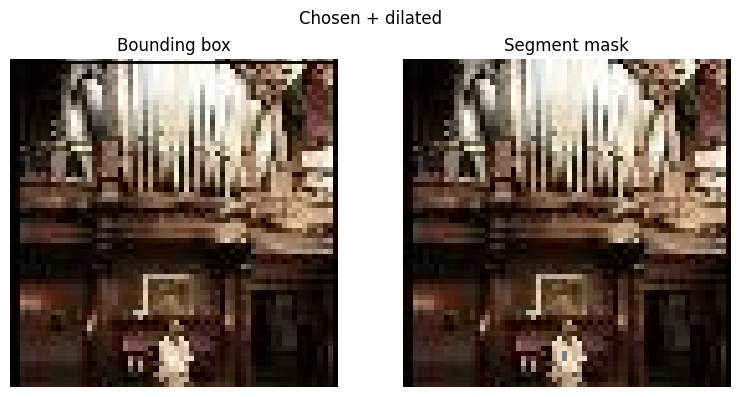

In [51]:
# DILATION

from scipy.ndimage import binary_dilation

SEGMENT_IDX = 1          # <-- change this manually after you look at the plots
DILATION_RADIUS = 2      # pixels; 0 means no dilation

chosen_segment = segments[SEGMENT_IDX]
bbox = chosen_segment["bbox"]
mask = chosen_segment["mask"]

if DILATION_RADIUS > 0:
    struct = np.ones((2 * DILATION_RADIUS + 1, 2 * DILATION_RADIUS + 1), dtype=bool)
    mask = binary_dilation(mask, structure=struct)

# recompute bbox from dilated mask, in case it changed
ys, xs = np.where(mask)
y_min, y_max = ys.min(), ys.max() + 1
x_min, x_max = xs.min(), xs.max() + 1
bbox = [int(x_min), int(y_min), int(x_max), int(y_max)]

print("Chosen segment:", SEGMENT_IDX)
print("Dilated bbox:", bbox)

show_segment_with_bbox(image_np, {"bbox": bbox, "mask": mask}, title="Chosen + dilated")

In [46]:
import numpy as np
import csv
from pathlib import Path
from scipy.ndimage import binary_dilation

# ============================================================
# 1) Get true TinyImageNet label for this image
# ============================================================

VAL_ANN_PATH = DATA_ROOT / "val" / "val_annotations.txt"
WNIDS_PATH   = DATA_ROOT / "wnids.txt"

# image name -> wnid
img_to_wnid = {}
with open(VAL_ANN_PATH, "r") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            fname, wnid = parts[0], parts[1]
            img_to_wnid[fname] = wnid

# wnid -> integer class index [0..199]
wnids = [line.strip() for line in open(WNIDS_PATH, "r") if line.strip()]
wnid_to_idx = {wnid: i for i, wnid in enumerate(wnids)}

current_img_name = all_images[IMG_INDEX].name
current_wnid     = img_to_wnid[current_img_name]
TRUE_LABEL       = wnid_to_idx[current_wnid]
NUM_CLASSES      = len(wnids)

print("Current image:", current_img_name)
print("WNID:", current_wnid)
print("True label index:", TRUE_LABEL, "/", NUM_CLASSES)

# ============================================================
# 2) Center-crop image & masks from 64x64 -> 56x56
#    (to match ONNX input: 3 x 56 x 56 -> 9408 inputs)
# ============================================================

TARGET_H, TARGET_W = 56, 56

H, W, C = image_np.shape
assert H == 64 and W == 64 and C == 3, f"Expected 64x64x3, got {image_np.shape}"

top    = (H - TARGET_H) // 2  # 4
left   = (W - TARGET_W) // 2  # 4
bottom = top + TARGET_H       # 60
right  = left + TARGET_W      # 60

# cropped image used for VNNLIB (56x56x3)
image_for_vnnlib = image_np[top:bottom, left:right, :]
print("Cropped image shape (for VNNLIB):", image_for_vnnlib.shape)

def crop_mask(mask_64x64: np.ndarray) -> np.ndarray:
    """Crop a 64x64 mask to the same central 56x56 region."""
    return mask_64x64[top:bottom, left:right]

# ============================================================
# 3) Bounds function: only mask region has epsilon, rest fixed
# ============================================================

def bounds_for_segment(image_np_cropped: np.ndarray,
                       mask_cropped: np.ndarray,
                       eps: float,
                       dilation_radius: int = 0):
    """
    image_np_cropped: H x W x C in [0,1], here 56x56x3
    mask_cropped: H x W bool; True = pixels allowed to move
    eps: epsilon for those pixels
    dilation_radius: dilate mask before using (0 = no dilation)

    Semantics:
      - outside mask: lb = ub = base  (no perturbation)
      - inside mask:  lb = base - eps, ub = base + eps (clamped to [0,1])
    """
    Hc, Wc, Cc = image_np_cropped.shape

    if dilation_radius > 0:
        struct = np.ones((2 * dilation_radius + 1, 2 * dilation_radius + 1), dtype=bool)
        mask_cropped = binary_dilation(mask_cropped, structure=struct)

    base = image_np_cropped.copy()

    # start with everything fixed
    lb = base.copy()
    ub = base.copy()

    ys, xs = np.where(mask_cropped)
    for y, x in zip(ys, xs):
        for c in range(Cc):
            v = base[y, x, c]
            lb[y, x, c] = np.clip(v - eps, 0.0, 1.0)
            ub[y, x, c] = np.clip(v + eps, 0.0, 1.0)

    # flatten (C, H, W) -> vector
    lb_flat = lb.transpose(2, 0, 1).reshape(-1)
    ub_flat = ub.transpose(2, 0, 1).reshape(-1)

    # sanity check: must be 3 * 56 * 56 = 9408
    assert len(lb_flat) == 3 * 56 * 56, f"Unexpected input length {len(lb_flat)}"
    assert len(ub_flat) == 3 * 56 * 56

    return lb_flat, ub_flat

# ============================================================
# 4) VNNLIB writer: matches your working TinyImageNet files
# ============================================================

def write_vnnlib(lb_flat,
                 ub_flat,
                 label: int,
                 num_classes: int,
                 out_path: Path):
    """
    lb_flat, ub_flat: 1D numpy arrays (length = 3*56*56 = 9408)
    label: true class index
    num_classes: total TinyImageNet classes (200)
    out_path: path to .vnnlib
    """
    out_path = Path(out_path)
    N = len(lb_flat)

    with out_path.open("w") as f:
        f.write(f"; Property with label: {label}.\n\n")

        # Inputs X_i
        for i in range(N):
            f.write(f"(declare-const X_{i} Real)\n")
        f.write("\n")

        # Outputs Y_i
        for i in range(num_classes):
            f.write(f"(declare-const Y_{i} Real)\n")
        f.write("\n")

        # Input constraints
        f.write("; Input constraints:\n")
        for i in range(N):
            f.write(f"(assert (>= X_{i} {lb_flat[i]:.6f}))\n")
            f.write(f"(assert (<= X_{i} {ub_flat[i]:.6f}))\n")
        f.write("\n")

        # Output constraints: your "misclassification exists" disjunction
        f.write("; Output constraints (there exists k != label with Y_k >= Y_label):\n")
        f.write("(assert (or\n")
        for k in range(num_classes):
            if k == label:
                continue
            f.write(f"    (and (>= Y_{k} Y_{label}))\n")
        f.write("))\n")

    print(f"Saved VNNLib property to: {out_path.resolve()}")

# ============================================================
# 5) Generate global + per-mask VNNLIBs and instances.csv
# ============================================================

# Folder structure matching your benchmark
VNNLIB_DIR      = Path("benchmarks/tinyimagenet_segmented/vnnlib")
VNNLIB_DIR.mkdir(parents=True, exist_ok=True)

IMG_BASENAME    = all_images[IMG_INDEX].stem  # e.g. "val_8165"
print("Using EPSILON =", EPSILON)

# This should match what vnncomp/abcrown sees in your log
ONNX_MODEL_PATH = "benchmarks/tinyimagenet_segmented/onnx/TinyImageNet_resnet_medium.onnx"
TIMEOUT         = 3600  # or 100 / whatever you want

csv_rows = []

# -------- 5a) Global epsilon (all pixels allowed to move with eps) --------
lb_global = np.clip(image_for_vnnlib - EPSILON, 0.0, 1.0)
ub_global = np.clip(image_for_vnnlib + EPSILON, 0.0, 1.0)

lb_global_flat = lb_global.transpose(2, 0, 1).reshape(-1)
ub_global_flat = ub_global.transpose(2, 0, 1).reshape(-1)

assert len(lb_global_flat) == 3 * 56 * 56

global_vnnlib_path = VNNLIB_DIR / f"{IMG_BASENAME}_global_eps_{EPSILON:.4f}.vnnlib"
write_vnnlib(
    lb_flat=lb_global_flat,
    ub_flat=ub_global_flat,
    label=TRUE_LABEL,
    num_classes=NUM_CLASSES,
    out_path=global_vnnlib_path,
)
csv_rows.append([ONNX_MODEL_PATH, str(global_vnnlib_path), TIMEOUT])

# -------- 5b) One VNNLIB per SAM2 segment: only that region has eps --------
segment_paths = []

for seg_idx, seg in enumerate(segments):
    full_mask        = seg["mask"].astype(bool)   # 64x64
    seg_mask_cropped = crop_mask(full_mask)       # 56x56

    lb_flat, ub_flat = bounds_for_segment(
        image_np_cropped=image_for_vnnlib,
        mask_cropped=seg_mask_cropped,
        eps=EPSILON,
        dilation_radius=DILATION_RADIUS,
    )

    seg_vnnlib_path = VNNLIB_DIR / f"{IMG_BASENAME}_seg{seg_idx}_eps_{EPSILON:.4f}.vnnlib"
    write_vnnlib(
        lb_flat=lb_flat,
        ub_flat=ub_flat,
        label=TRUE_LABEL,
        num_classes=NUM_CLASSES,
        out_path=seg_vnnlib_path,
    )

    segment_paths.append(seg_vnnlib_path)
    csv_rows.append([ONNX_MODEL_PATH, str(seg_vnnlib_path), TIMEOUT])

print("\nCreated VNNLIB files:")
print("  Global:", global_vnnlib_path)
for p in segment_paths:
    print("  Segment:", p)

# -------- 5c) Write instances.csv in the same vnnlib folder --------
CSV_PATH = VNNLIB_DIR / "instances.csv"

with CSV_PATH.open("w", newline="") as f:
    writer = csv.writer(f)
    # vnncomp-style: no header, just rows
    writer.writerows(csv_rows)

print("\nSaved instances.csv at:", CSV_PATH.resolve())

Current image: val_8165.JPEG
WNID: n03854065
True label index: 19 / 200
Cropped image shape (for VNNLIB): (56, 56, 3)
Using EPSILON = 0.00039
Saved VNNLib property to: /Users/zd3504phd/Desktop/XAIV/benchmarks/tinyimagenet_segmented/vnnlib/val_8165_global_eps_0.0004.vnnlib
Saved VNNLib property to: /Users/zd3504phd/Desktop/XAIV/benchmarks/tinyimagenet_segmented/vnnlib/val_8165_seg0_eps_0.0004.vnnlib
Saved VNNLib property to: /Users/zd3504phd/Desktop/XAIV/benchmarks/tinyimagenet_segmented/vnnlib/val_8165_seg1_eps_0.0004.vnnlib
Saved VNNLib property to: /Users/zd3504phd/Desktop/XAIV/benchmarks/tinyimagenet_segmented/vnnlib/val_8165_seg2_eps_0.0004.vnnlib

Created VNNLIB files:
  Global: benchmarks/tinyimagenet_segmented/vnnlib/val_8165_global_eps_0.0004.vnnlib
  Segment: benchmarks/tinyimagenet_segmented/vnnlib/val_8165_seg0_eps_0.0004.vnnlib
  Segment: benchmarks/tinyimagenet_segmented/vnnlib/val_8165_seg1_eps_0.0004.vnnlib
  Segment: benchmarks/tinyimagenet_segmented/vnnlib/val_8165_seg

In [47]:
import numpy as np
from scipy.ndimage import binary_dilation

def bounds_for_segment(image_np: np.ndarray, mask: np.ndarray, eps: float, dilation_radius: int = 0):
    """
    image_np: H x W x C in [0,1]
    mask: H x W boolean array; True = pixels where we allow perturbation
    eps: epsilon for those pixels
    dilation_radius: dilate the mask before using (0 = no dilation)
    """
    H, W, C = image_np.shape

    if dilation_radius > 0:
        struct = np.ones((2 * dilation_radius + 1, 2 * dilation_radius + 1), dtype=bool)
        mask = binary_dilation(mask, structure=struct)

    base = image_np.copy()
    lb = base.copy()
    ub = base.copy()

    # Allow +/- eps only inside the mask; outside the mask, lb=ub=base (no perturbation)
    ys, xs = np.where(mask)
    for y, x in zip(ys, xs):
        for c in range(C):
            lb[y, x, c] = np.clip(base[y, x, c] - eps, 0.0, 1.0)
            ub[y, x, c] = np.clip(base[y, x, c] + eps, 0.0, 1.0)

    # Flatten as (C, H, W) → vector
    lb_flat = lb.transpose(2, 0, 1).reshape(-1)
    ub_flat = ub.transpose(2, 0, 1).reshape(-1)
    return lb_flat, ub_flat

In [48]:
from pathlib import Path

def write_vnnlib_for_segment(lb_flat, ub_flat, label, num_classes, out_path):
    """
    lb_flat, ub_flat: 1D numpy arrays with per-pixel lower/upper bounds
    label: true class index
    num_classes: total number of classes (TinyImageNet = 200)
    out_path: path to the .vnnlib file
    """
    out_path = Path(out_path)
    N = len(lb_flat)

    with out_path.open("w") as f:
        f.write(f"; Property with label: {label}.\n\n")

        # Declare input X_i
        for i in range(N):
            f.write(f"(declare-const X_{i} Real)\n")
        f.write("\n")

        # Declare outputs Y_i
        for i in range(num_classes):
            f.write(f"(declare-const Y_{i} Real)\n")
        f.write("\n")

        # Input constraints
        f.write("; Input constraints:\n")
        for i in range(N):
            f.write(f"(assert (>= X_{i} {lb_flat[i]:.6f}))\n")
            f.write(f"(assert (<= X_{i} {ub_flat[i]:.6f}))\n")
        f.write("\n")

        # Output constraints: existence of a misclassification
        f.write("; Output constraints (there exists some class != label with Y_k >= Y_label):\n")
        f.write("(assert (or\n")
        for k in range(num_classes):
            if k == label:
                continue
            f.write(f"    (and (>= Y_{k} Y_{label}))\n")
        f.write("))\n")

    print(f"Saved VNNLib property to: {out_path.resolve()}")

In [49]:
from pathlib import Path
import numpy as np

# Folder to store VNNLIBs
VNNLIB_DIR = Path("benchmarks/tinyimagenet_segmented/vnnlib")
VNNLIB_DIR.mkdir(exist_ok=True)

# Base name from the image file, e.g. "val_3119"
IMG_BASENAME = all_images[IMG_INDEX].stem

# Use the same EPSILON as above
print("Using EPSILON =", EPSILON)

# -------- 1) Global epsilon VNNLIB (full image perturbed) --------
lb_global = np.clip(image_np - EPSILON, 0.0, 1.0)
ub_global = np.clip(image_np + EPSILON, 0.0, 1.0)

lb_global_flat = lb_global.transpose(2, 0, 1).reshape(-1)
ub_global_flat = ub_global.transpose(2, 0, 1).reshape(-1)

global_vnnlib_path = VNNLIB_DIR / f"{IMG_BASENAME}_global_eps_{EPSILON:.4f}.vnnlib"
write_vnnlib_for_segment(
    lb_flat=lb_global_flat,
    ub_flat=ub_global_flat,
    label=TRUE_LABEL,
    num_classes=NUM_CLASSES,
    out_path=global_vnnlib_path,
)

# -------- 2) One VNNLIB per SAM2 segment --------
segment_paths = []
for seg_idx, seg in enumerate(segments):
    seg_mask = seg["mask"].astype(bool)

    lb_flat, ub_flat = bounds_for_segment(
        image_np=image_np,
        mask=seg_mask,
        eps=EPSILON,
        dilation_radius=DILATION_RADIUS, 
    )

    seg_vnnlib_path = VNNLIB_DIR / f"{IMG_BASENAME}_seg{seg_idx}_eps_{EPSILON:.4f}.vnnlib"
    write_vnnlib_for_segment(
        lb_flat=lb_flat,
        ub_flat=ub_flat,
        label=TRUE_LABEL,
        num_classes=NUM_CLASSES,
        out_path=seg_vnnlib_path,
    )
    segment_paths.append(seg_vnnlib_path)

print("\nCreated VNNLIB files:")
print("  Global:", global_vnnlib_path)
for p in segment_paths:
    print("  Segment:", p)

Using EPSILON = 0.00039
Saved VNNLib property to: /Users/zd3504phd/Desktop/XAIV/benchmarks/tinyimagenet_segmented/vnnlib/val_8165_global_eps_0.0004.vnnlib
Saved VNNLib property to: /Users/zd3504phd/Desktop/XAIV/benchmarks/tinyimagenet_segmented/vnnlib/val_8165_seg0_eps_0.0004.vnnlib
Saved VNNLib property to: /Users/zd3504phd/Desktop/XAIV/benchmarks/tinyimagenet_segmented/vnnlib/val_8165_seg1_eps_0.0004.vnnlib
Saved VNNLib property to: /Users/zd3504phd/Desktop/XAIV/benchmarks/tinyimagenet_segmented/vnnlib/val_8165_seg2_eps_0.0004.vnnlib

Created VNNLIB files:
  Global: benchmarks/tinyimagenet_segmented/vnnlib/val_8165_global_eps_0.0004.vnnlib
  Segment: benchmarks/tinyimagenet_segmented/vnnlib/val_8165_seg0_eps_0.0004.vnnlib
  Segment: benchmarks/tinyimagenet_segmented/vnnlib/val_8165_seg1_eps_0.0004.vnnlib
  Segment: benchmarks/tinyimagenet_segmented/vnnlib/val_8165_seg2_eps_0.0004.vnnlib


In [50]:
import numpy as np
import csv
from pathlib import Path
from scipy.ndimage import binary_dilation

# =========================
# 1) Get true label from TinyImageNet
# =========================

VAL_ANN_PATH = DATA_ROOT / "val" / "val_annotations.txt"
WNIDS_PATH = DATA_ROOT / "wnids.txt"

# Map: image name -> WordNet ID (wnid)
img_to_wnid = {}
with open(VAL_ANN_PATH, "r") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            fname, wnid = parts[0], parts[1]
            img_to_wnid[fname] = wnid

# Map: wnid -> integer class index [0, 199]
wnids = [line.strip() for line in open(WNIDS_PATH, "r") if line.strip()]
wnid_to_idx = {wnid: i for i, wnid in enumerate(wnids)}

current_img_name = all_images[IMG_INDEX].name
current_wnid = img_to_wnid[current_img_name]
TRUE_LABEL = wnid_to_idx[current_wnid]
NUM_CLASSES = len(wnids)

print("Current image:", current_img_name)
print("WNID:", current_wnid)
print("True label index:", TRUE_LABEL, "/", NUM_CLASSES)


# =========================
# 2) Helper: bounds for a segment
# =========================

def bounds_for_segment(image_np: np.ndarray,
                       mask: np.ndarray,
                       eps: float,
                       dilation_radius: int = 0):
    """
    image_np: H x W x C in [0,1]
    mask: H x W boolean array; True = pixels where we allow perturbation
    eps: epsilon for those pixels
    dilation_radius: dilate mask before using (0 = no dilation)
    """
    H, W, C = image_np.shape

    if dilation_radius > 0:
        struct = np.ones((2 * dilation_radius + 1, 2 * dilation_radius + 1), dtype=bool)
        mask = binary_dilation(mask, structure=struct)

    base = image_np.copy()
    lb = base.copy()
    ub = base.copy()

    # Allow +/- eps only inside the mask; outside: lb=ub=base
    ys, xs = np.where(mask)
    for y, x in zip(ys, xs):
        for c in range(C):
            lb[y, x, c] = np.clip(base[y, x, c] - eps, 0.0, 1.0)
            ub[y, x, c] = np.clip(base[y, x, c] + eps, 0.0, 1.0)

    # Flatten (C, H, W) → vector
    lb_flat = lb.transpose(2, 0, 1).reshape(-1)
    ub_flat = ub.transpose(2, 0, 1).reshape(-1)
    return lb_flat, ub_flat


# =========================
# 3) Helper: write one VNNLIB
# =========================

def write_vnnlib_for_segment(lb_flat,
                             ub_flat,
                             label,
                             num_classes,
                             out_path: Path):
    """
    lb_flat, ub_flat: 1D numpy arrays
    label: true class index
    num_classes: total classes (TinyImageNet = 200)
    out_path: Path to .vnnlib
    """
    out_path = Path(out_path)
    N = len(lb_flat)

    with out_path.open("w") as f:
        f.write(f"; Property with label: {label}.\n\n")

        # Declare input X_i
        for i in range(N):
            f.write(f"(declare-const X_{i} Real)\n")
        f.write("\n")

        # Declare outputs Y_i
        for i in range(num_classes):
            f.write(f"(declare-const Y_{i} Real)\n")
        f.write("\n")

        # Input constraints
        f.write("; Input constraints:\n")
        for i in range(N):
            f.write(f"(assert (>= X_{i} {lb_flat[i]:.6f}))\n")
            f.write(f"(assert (<= X_{i} {ub_flat[i]:.6f}))\n")
        f.write("\n")

        # Output constraints: existence of a misclassification
        f.write("; Output constraints (there exists k != label with Y_k >= Y_label):\n")
        f.write("(assert (or\n")
        for k in range(num_classes):
            if k == label:
                continue
            f.write(f"    (and (>= Y_{k} Y_{label}))\n")
        f.write("))\n")

    print(f"Saved VNNLib property to: {out_path.resolve()}")


# =========================
# 4) Generate VNNLIBs + CSV
# =========================

VNNLIB_DIR = Path("vnnlib_out")
VNNLIB_DIR.mkdir(exist_ok=True)

IMG_BASENAME = all_images[IMG_INDEX].stem  # e.g. "val_3119"
print("Using EPSILON =", EPSILON)

# ---- config for CSV ----
ONNX_MODEL_NAME = "TinyImageNet_resnet_medium.onnx"  # change if needed
TIMEOUT = 100  # seconds, or whatever you use in vnncomp
csv_rows = []

# ---- 4a) Global epsilon over whole image ----
lb_global = np.clip(image_np - EPSILON, 0.0, 1.0)
ub_global = np.clip(image_np + EPSILON, 0.0, 1.0)

lb_global_flat = lb_global.transpose(2, 0, 1).reshape(-1)
ub_global_flat = ub_global.transpose(2, 0, 1).reshape(-1)

global_vnnlib_path = VNNLIB_DIR / f"{IMG_BASENAME}_global_eps_{EPSILON:.4f}.vnnlib"
write_vnnlib_for_segment(
    lb_flat=lb_global_flat,
    ub_flat=ub_global_flat,
    label=TRUE_LABEL,
    num_classes=NUM_CLASSES,
    out_path=global_vnnlib_path,
)

csv_rows.append([ONNX_MODEL_NAME, global_vnnlib_path.name, TIMEOUT])

# ---- 4b) One VNNLIB per SAM2 segment ----
segment_paths = []
for seg_idx, seg in enumerate(segments):
    seg_mask = seg["mask"].astype(bool)

    lb_flat, ub_flat = bounds_for_segment(
        image_np=image_np,
        mask=seg_mask,
        eps=EPSILON,
        dilation_radius=DILATION_RADIUS,
    )

    seg_vnnlib_path = VNNLIB_DIR / f"{IMG_BASENAME}_seg{seg_idx}_eps_{EPSILON:.4f}.vnnlib"
    write_vnnlib_for_segment(
        lb_flat=lb_flat,
        ub_flat=ub_flat,
        label=TRUE_LABEL,
        num_classes=NUM_CLASSES,
        out_path=seg_vnnlib_path,
    )
    segment_paths.append(seg_vnnlib_path)
    csv_rows.append([ONNX_MODEL_NAME, seg_vnnlib_path.name, TIMEOUT])

print("\nCreated VNNLIB files:")
print("  Global:", global_vnnlib_path)
for p in segment_paths:
    print("  Segment:", p)

# ---- 4c) Write instances.csv ----
CSV_PATH = VNNLIB_DIR / "instances.csv"  # or Path("instances.csv") if you want it at root

with CSV_PATH.open("w", newline="") as f:
    writer = csv.writer(f)
    # no header, to match your original script
    # writer.writerow(["onnx", "vnnlib", "timeout"])
    writer.writerows(csv_rows)

print("\nSaved instances.csv at:", CSV_PATH.resolve())

Current image: val_8165.JPEG
WNID: n03854065
True label index: 19 / 200
Using EPSILON = 0.00039
Saved VNNLib property to: /Users/zd3504phd/Desktop/XAIV/vnnlib_out/val_8165_global_eps_0.0004.vnnlib
Saved VNNLib property to: /Users/zd3504phd/Desktop/XAIV/vnnlib_out/val_8165_seg0_eps_0.0004.vnnlib
Saved VNNLib property to: /Users/zd3504phd/Desktop/XAIV/vnnlib_out/val_8165_seg1_eps_0.0004.vnnlib
Saved VNNLib property to: /Users/zd3504phd/Desktop/XAIV/vnnlib_out/val_8165_seg2_eps_0.0004.vnnlib

Created VNNLIB files:
  Global: vnnlib_out/val_8165_global_eps_0.0004.vnnlib
  Segment: vnnlib_out/val_8165_seg0_eps_0.0004.vnnlib
  Segment: vnnlib_out/val_8165_seg1_eps_0.0004.vnnlib
  Segment: vnnlib_out/val_8165_seg2_eps_0.0004.vnnlib

Saved instances.csv at: /Users/zd3504phd/Desktop/XAIV/vnnlib_out/instances.csv
